<a href="https://colab.research.google.com/github/mafgit/developershub-internship-tasks/blob/master/Task_3_Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 3: Heart Disease Prediction

In [148]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "redwankarimsony/heart-disease-data",
  'heart_disease_uci.csv',
)

df.head()

/tmp/ipykernel_1650/3267052068.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'heart-disease-data' dataset.


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [149]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


### Imputation and cleaning in dataset

In [151]:
cleaned_df = df.drop(['dataset', 'id'], axis=1)
median_cols = ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
cleaned_df[median_cols].fillna(cleaned_df[median_cols].median(), inplace=True)

mode_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']
cleaned_df[mode_cols].fillna(cleaned_df[mode_cols].mode(), inplace=True)

cleaned_df.dropna(inplace=True)
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 748
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       299 non-null    int64  
 1   sex       299 non-null    object 
 2   cp        299 non-null    object 
 3   trestbps  299 non-null    float64
 4   chol      299 non-null    float64
 5   fbs       299 non-null    object 
 6   restecg   299 non-null    object 
 7   thalch    299 non-null    float64
 8   exang     299 non-null    object 
 9   oldpeak   299 non-null    float64
 10  slope     299 non-null    object 
 11  ca        299 non-null    float64
 12  thal      299 non-null    object 
 13  num       299 non-null    int64  
dtypes: float64(5), int64(2), object(7)
memory usage: 35.0+ KB


/tmp/ipykernel_1650/482329673.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df[median_cols].fillna(cleaned_df[median_cols].median(), inplace=True)
/tmp/ipykernel_1650/482329673.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df[mode_cols].fillna(cleaned_df[mode_cols].mode(), inplace=True)


### Encoding categorical columns & converting to binary classification from multi-class (as hinted in question)

In [152]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

cleaned_df['risk'] = cleaned_df['thal'].apply(lambda x: 1 if x != 'normal' else 0)
cleaned_df.drop('thal', axis=1, inplace=True)

encoder = LabelEncoder()
encode_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']
for col in encode_cols:
    cleaned_df[col] = encoder.fit_transform(cleaned_df[col])

X = cleaned_df.drop('risk', axis=1)
y = cleaned_df['risk']

### Correlation matrix for EDA

<Axes: >

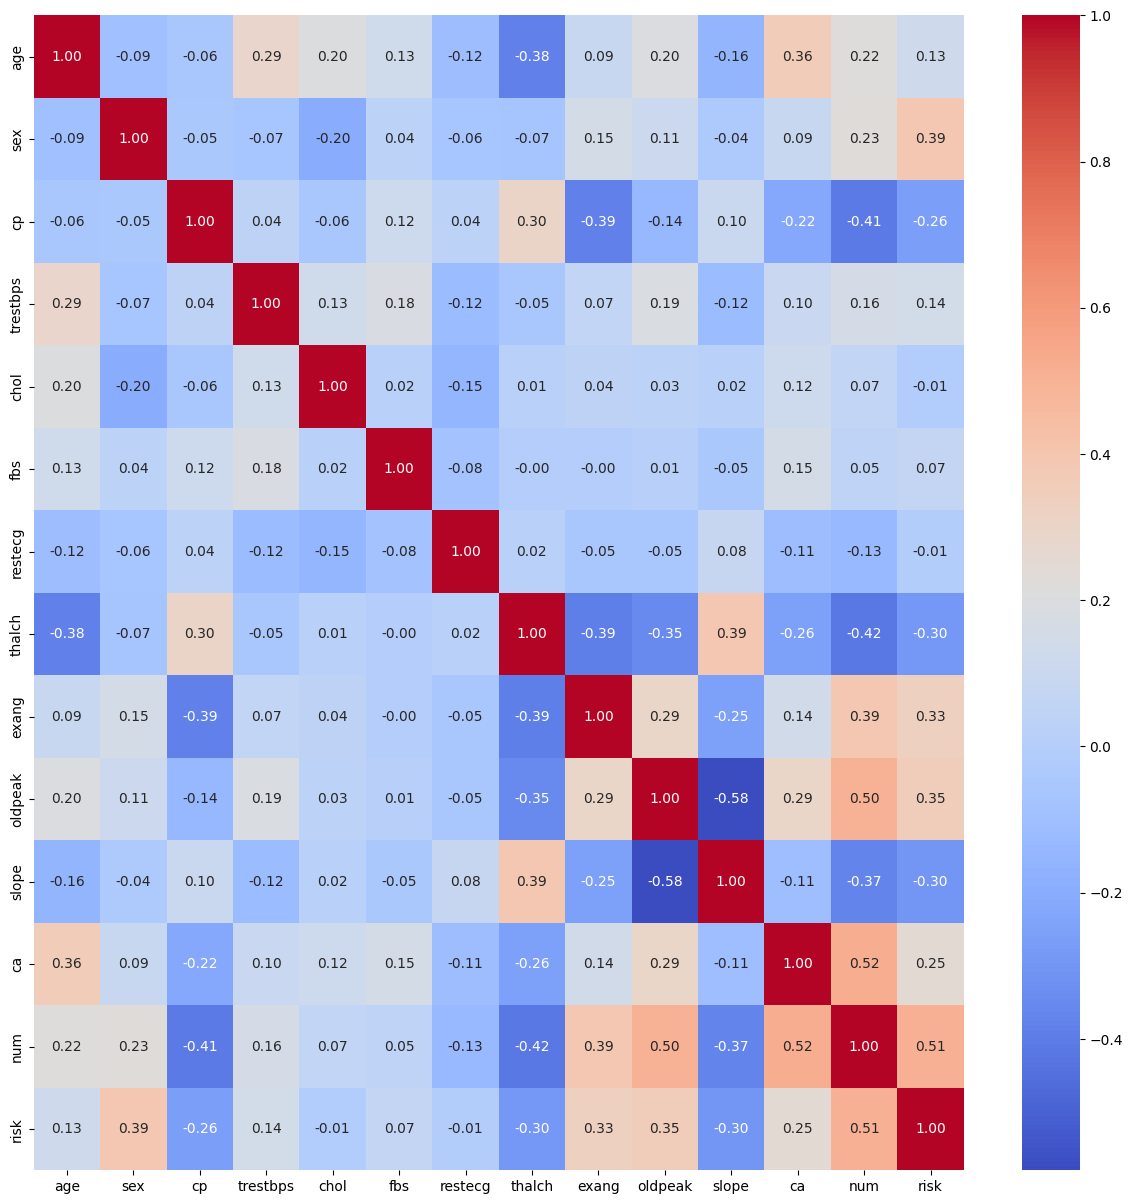

In [167]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = cleaned_df.corr()
plt.figure(figsize=(15, 15))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

### Splitting data

In [154]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

### Scaling

In [155]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Training Model

In [156]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

model_lr = LogisticRegression()
model_rf = RandomForestClassifier()

model_lr.fit(X_train, y_train)
model_rf.fit(X_train, y_train)

RandomForestClassifier()

In [157]:
y_pred_lr = model_lr.predict(X_test)
y_pred_rf = model_rf.predict(X_test)

### Accuracy
- Random Forest is performing better so choosing that for next steps

In [158]:
from sklearn.metrics import accuracy_score

acc_lr = accuracy_score(y_test, y_pred_lr)
acc_rf = accuracy_score(y_test, y_pred_rf)

print('LR Acc:', acc_lr, ', RF Acc:',acc_rf)

LR Acc: 0.7111111111111111 , RF Acc: 0.7777777777777778


### Confusion Matrix

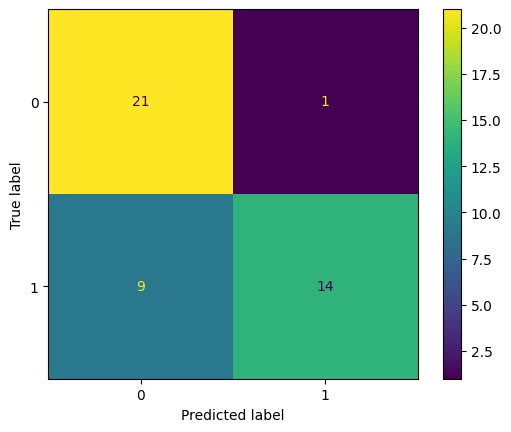

In [161]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
# confusion_matrix(y_test, y_pred_rf)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)

### ROC Curve

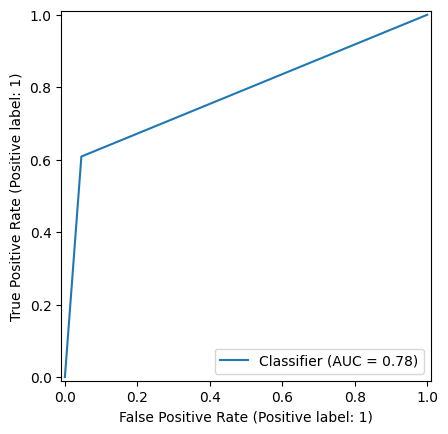

In [162]:
RocCurveDisplay.from_predictions(y_test, y_pred_rf)